In [4]:
#finetune ConvNeXt
import timm
import torch.nn as nn
import gdown

class LocationTemporalClassifier(nn.Module):
    def __init__(self, num_species=854):
      super().__init__()

      #fully connected classifier using location, date, time
      self.classifier = nn.Sequential(
        nn.Linear(4 + 2 + 2, 256),  #lat sin cos, lon sin cos, day sin cos, hour sin cos
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(128, num_species)
      )

    def forward(self, catd_encd_metadata):
      #input is all encoded metadata concatenated
      return self.classifier(catd_encd_metadata)


class ConvnextFTClassifier(nn.Module):
    def __init__(self, num_species=854):
        super().__init__()

        #load in convnext
        self.backbone = timm.create_model(
            'convnext_nano.in12k_ft_in1k', #use convnext nano pretrained on imagenet12k and ft on 1k, 15.62M params
            pretrained=True,
            num_classes=0,#remove head
        )

        #head
        backbone_features = self.backbone.num_features #768
        self.classifier = nn.Sequential(
            nn.LayerNorm(backbone_features),
            nn.Dropout(0.2),
            nn.Linear(backbone_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_species)
        )

    def forward(self, image):
        features = self.backbone(image)  #image input with dimensions as #[batch, flattened]
        return self.classifier(features)

class SpeciesClassifier(nn.Module):
  def __init__(self, num_species=854, pretrained=False):
    super().__init__()

    #image classifier
    self.image_classifier = ConvnextFTClassifier(num_species)
    #location, date, time classifier
    self.metadata_classifier = LocationTemporalClassifier(num_species)

    if pretrained:
        self._load_pretrained_model()

  def _load_pretrained_model(self):
    file_id = '1vG0T6FLkJEJBMJjRH1qnJSQFMpRDZ2Vp'
    url = f'https://drive.google.com/uc?id={file_id}'
    path="model_epoch_36.pt"
    gdown.download(url, path, quiet=False)
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    checkpoint = torch.load(path, map_location=DEVICE)
    self.load_state_dict(checkpoint['model_state_dict'])
    print("Loaded pretrained model weights")


  def forward(self, image, catd_encd_metadata, has_metadata):
    image_output = self.image_classifier(image)
    metadata_output = self.metadata_classifier(catd_encd_metadata)
    metadata_output = metadata_output*has_metadata.unsqueeze(1)
    logits = image_output + metadata_output
    return logits





implementation for combining location and image from this paper: https://arxiv.org/pdf/1906.01737

In [5]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import numpy as np
from google.colab import drive
# import preprocess as pp
from datetime import datetime
import os
from timm.data.mixup import Mixup
import time
import gdown

def sinusoidal_encoding(value, max_value):
    """
    Encodes value by transforming with sine and cosine.
    Allows representation of cyclical values.
    :param value: the value to be encoded
    :param max_value: max value that value can take before cycling
    :return: (sine, cosine) each between [-1, 1]
    """
    if value is None:
        return None, None
    angle = np.pi*value/max_value
    return np.sin(angle), np.cos(angle)


class CustomDataset(Dataset):
  def __init__(self, img_paths, metadata, labels, base_path, transform):
    self.image_paths = img_paths
    self.metadata = metadata
    self.labels = labels
    self.base_path = base_path
    self.transform = transform
    #when training, do data augmentation
    # so model sees different augmented data every epoch

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, idx):
    #load single image
    full_path = os.path.join(self.base_path, self.image_paths[idx])
    image = Image.open(full_path).convert('RGB')
    #transform image
    image_tensor = self.transform(image)

    #[lat, lon, day_of_year, minute_of_day]
    metadata = self.metadata[idx]
    #return a tensor of encoded values
    #if None for any, make 0 tensor, set flag to 1
    if metadata[0] is None or metadata[1] is None or metadata[2] is None or metadata[3] is None:
      md_tensor = torch.zeros(8, dtype=torch.float32)
      has_md = torch.tensor(0, dtype=torch.float32)
    else:
      lat_sin, lat_cos = sinusoidal_encoding(metadata[0], 90)
      lon_sin, lon_cos = sinusoidal_encoding(metadata[1], 180)
      day_sin, day_cos = sinusoidal_encoding(metadata[2], 366)
      min_sin, min_cos = sinusoidal_encoding(metadata[3], 1440)
      md_tensor = torch.tensor([lat_sin, lat_cos, lon_sin, lon_cos, day_sin, day_cos, min_sin, min_cos], dtype=torch.float32)
      has_md = torch.tensor(1, dtype=torch.float32)

    label = torch.tensor(self.labels[idx], dtype=torch.long)

    return image_tensor, md_tensor, label, has_md


def train_epoch(model, dataloader, optimizer, loss_fn, device):
  """
  Trains a model for one epoch.
  return: returns the average loss per epoch and a list of loss for each batch
  """
  model.train()
  batch_loss = []

  for index, (images, metadata, labels, has_md) in enumerate(dataloader):
    #check progress within epoch
    print(f"\tbatch {index+1}/{len(dataloader)},", end="")
    images = images.to(device)
    metadata = metadata.to(device)
    labels = labels.to(device)
    has_md = has_md.to(device)
    #pred and calculate loss
    outputs = model(images, metadata, has_md)
    loss = loss_fn(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    #track loss per batch
    batch_loss.append(loss.item())
    print(f" loss: {loss.item()}")

  avg_loss = sum(batch_loss)/len(dataloader)
  return avg_loss, batch_loss

def validate(model, dataloader, loss_fn, device):
  """
  Validates a model for one epoch.
  return: returns the average loss per epoch and a list of loss for each batch
  and the average accuracy per epoch
  """
  model.eval()
  batch_loss = []
  total_correct = 0
  total_samples = 0

  with torch.no_grad():
    for idx, (images, metadata, labels, has_md) in enumerate(dataloader):
      print(f"\tbatch {idx+1}/{len(dataloader)},", end="")
      images = images.to(device)
      metadata = metadata.to(device)
      labels = labels.to(device)
      has_md = has_md.to(device)
      #pred and calculate loss
      outputs = model(images, metadata, has_md)
      loss = loss_fn(outputs, labels)
      #track loss per batch
      batch_loss.append(loss.item())
      print(f" loss: {loss.item()}")
      #calculate accuracy
      _, predicted = outputs.max(1)
      total_correct += predicted.eq(labels).sum().item()
      total_samples += labels.size(0)

  avg_loss = sum(batch_loss) / len(dataloader)
  avg_acc = 100.0 * total_correct / total_samples
  return avg_loss, batch_loss, avg_acc



In [20]:
#the training data and validation data are stored as zip files on my gdrive
#copying them here to local colab storage then unzipping was by far the fastest
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/train_mini.zip /content/
!unzip -q /content/train_mini.zip -d /content/
!cp /content/drive/MyDrive/val.zip /content/
!unzip -q /content/val.zip -d /content/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
#validate files copied and unzipped right, should be 8540, 42700
!ls /content/val | wc -l
!ls /content/train_mini | wc -l

8540
42700


In [4]:
#start training here
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import matplotlib.pyplot as plt
import torch
from torch.utils.data import default_collate
from torchvision.transforms import v2

#hyperparameters
NUM_CLASSES = 854
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.05
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using {DEVICE}\n")

#want to save model and metrics
save_dir = '/content/drive/MyDrive/checkpoints'
os.makedirs(save_dir, exist_ok=True)

using cpu



In [5]:
#IF CONTINUEING TRAINING FROM CHECKPOINT
train_losses = []
val_losses = []
val_accs = []

#define model and functions
model = SpeciesClassifier()
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1) #label smoothing might be better for limited data

#get all previous models to get latest one from gdrive
checkpoint_files = sorted([f for f in os.listdir(save_dir) if f.startswith('model_epoch_')])
print(bool(checkpoint_files))
if checkpoint_files:
  latest_checkpoint = f'{save_dir}/{checkpoint_files[-1]}'
  checkpoint = torch.load(latest_checkpoint, map_location=DEVICE)
  #load latest model and functions
  model.load_state_dict(checkpoint['model_state_dict'])
  # model.to(DEVICE)
  optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
  #apparently this fixes device issues, well see
  # for state in optimizer.state.values():
  #   for k, v in state.items():
  #     if isinstance(v, torch.Tensor):
  #       state[k] = v.to(DEVICE)
  start_epoch = checkpoint['epoch'] + 1
  #load previous metrics
  train_losses = checkpoint['train_losses']
  val_losses = checkpoint['val_losses']
  val_accs = checkpoint['val_accs']

  print(f'loaded model trained to epoch {checkpoint["epoch"]}')
else:
  start_epoch = 0


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/62.4M [00:00<?, ?B/s]

False


In [24]:
#load in train data, must move these files into local colab storage
X_train_images = np.load('train_image_paths.npy', allow_pickle=True)
X_train_metadata = np.load('train_metadata.npy', allow_pickle=True)
Y_train_labels = np.load('train_labels.npy', allow_pickle=True)
#load in validation data
X_val_images = np.load('val_image_paths.npy', allow_pickle=True)
X_val_metadata = np.load('val_metadata.npy', allow_pickle=True)
Y_val_labels = np.load('val_labels.npy', allow_pickle=True)

#define collate function for data augmentation
cutmix = v2.CutMix(num_classes=NUM_CLASSES)
mixup = v2.MixUp(num_classes=NUM_CLASSES)
cutmix_or_mixup = v2.RandomChoice([cutmix, mixup])
def collate_fn(batch):
  #get each data list
  images = [item[0] for item in batch]
  metadata = [item[1] for item in batch]
  labels = [item[2] for item in batch]
  has_md = [item[3] for item in batch]
  #collate them seperately
  images = default_collate(images)
  metadata = default_collate(metadata)
  labels = default_collate(labels)
  has_md = default_collate(has_md)
  #ppply cutmix and mixmup to images and labels only
  images, labels = cutmix_or_mixup(images, labels)
  return images, metadata, labels, has_md

#get transforms
data_config = timm.data.resolve_model_data_config(model)
train_transforms = timm.data.create_transform(**data_config, is_training=True)
val_transforms = timm.data.create_transform(**data_config, is_training=False)

base_path = '/content/'
#create train dataset and loader
train_dataset = CustomDataset(X_train_images, X_train_metadata, Y_train_labels, base_path, train_transforms)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
#create val dataset and loader
val_dataset = CustomDataset(X_val_images, X_val_metadata, Y_val_labels, base_path, val_transforms)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

#training loop
best_val_acc = 0
for epoch in range(start_epoch, EPOCHS):
  print(f"Epoch {epoch+1}/{EPOCHS}")

  avg_train_loss, batch_train_loss = train_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
  avg_val_loss, batch_val_loss, avg_val_acc = validate(model, val_loader, loss_fn, DEVICE)
  scheduler.step() #step per epoch, not per batch, learned that the hard way

  #concat this epochs values to lists
  train_losses.extend(batch_train_loss)
  val_losses.extend(batch_val_loss)
  val_accs.append(avg_val_acc)

  print(f"Avg Train Loss: {avg_train_loss}, Val Loss: {avg_val_loss}, Val Acc: {avg_val_acc}%")

  #save model after every epoch
  checkpoint_path = f'{save_dir}/model_epoch_{epoch}.pt'
  torch.save({
      'epoch': epoch,
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict(),
      'train_losses': train_losses,
      'val_losses': val_losses,
      'val_accs': val_accs,
  }, checkpoint_path)
  print(f'Saved checkpoint to {checkpoint_path}')



Epoch 33/50
	batch 1/668, loss: 3.223568916320801
	batch 2/668, loss: 4.829764366149902
	batch 3/668, loss: 4.296464920043945
	batch 4/668, loss: 4.696348667144775
	batch 5/668, loss: 4.5998430252075195
	batch 6/668, loss: 4.399753570556641
	batch 7/668, loss: 3.549731969833374
	batch 8/668, loss: 4.4254608154296875
	batch 9/668, loss: 3.922379732131958
	batch 10/668, loss: 4.157144546508789
	batch 11/668, loss: 3.8709492683410645
	batch 12/668, loss: 4.474667549133301
	batch 13/668, loss: 3.99290132522583
	batch 14/668, loss: 4.661910057067871
	batch 15/668, loss: 3.349335193634033
	batch 16/668, loss: 4.154364585876465
	batch 17/668, loss: 3.399099349975586
	batch 18/668, loss: 4.144082069396973
	batch 19/668, loss: 2.8744373321533203
	batch 20/668, loss: 2.3448259830474854
	batch 21/668, loss: 3.6455397605895996
	batch 22/668, loss: 3.185638427734375
	batch 23/668, loss: 4.132962703704834
	batch 24/668, loss: 4.014300346374512
	batch 25/668, loss: 3.5525784492492676
	batch 26/668, l

KeyboardInterrupt: 

In [33]:
#get top 5 accuracy
def calculate_top5_accuracy(model, dataloader, device):
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
    for idx, (images, metadata, labels, has_md) in enumerate(val_loader):
      print(f"\tbatch {idx+1}/{len(val_loader)}")
      images = images.to(DEVICE)
      metadata = metadata.to(DEVICE)
      labels = labels.to(DEVICE)
      has_md = has_md.to(DEVICE)
      #pred and calculate loss
      outputs = model(images, metadata, has_md)
      # Get top 5 predictions for each sample
      _, top5_pred = outputs.topk(5, dim=1, largest=True, sorted=True)
      # Check if true label is in top 5 predictions
      # Expand labels to compare with top5_pred
      labels_expanded = labels.view(-1, 1).expand_as(top5_pred)
      correct += (top5_pred == labels_expanded).sum().item()
      total += labels.size(0)
  top5_acc = 100 * correct / total
  return top5_acc

#get top 5 accuracy for all checkpointed model
models_t5acc = []
checkpoint_files = sorted([f for f in os.listdir(save_dir) if f.startswith('model_epoch_')])
for cp in checkpoint_files:
  checkpoint_pth = f'{save_dir}/{cp}'
  checkpoint = torch.load(checkpoint_pth)
  #load model and functions
  model.load_state_dict(checkpoint['model_state_dict'])
  model.to(DEVICE)
  epoch = checkpoint['epoch']
  if int(epoch) <=27:
    continue
  print(epoch)
  top5_acc = calculate_top5_accuracy(model, val_loader, DEVICE)
  models_t5acc.append(top5_acc)
  print(f'model trained to epoch {checkpoint["epoch"]}, top 5 accuracy: {top5_acc}%')

np.save('top5acc0-15', models_t5acc)

28
	batch 1/134
	batch 2/134
	batch 3/134
	batch 4/134
	batch 5/134
	batch 6/134
	batch 7/134
	batch 8/134
	batch 9/134
	batch 10/134
	batch 11/134
	batch 12/134
	batch 13/134
	batch 14/134
	batch 15/134
	batch 16/134
	batch 17/134
	batch 18/134
	batch 19/134
	batch 20/134
	batch 21/134
	batch 22/134
	batch 23/134
	batch 24/134
	batch 25/134
	batch 26/134
	batch 27/134
	batch 28/134
	batch 29/134
	batch 30/134
	batch 31/134
	batch 32/134
	batch 33/134
	batch 34/134
	batch 35/134
	batch 36/134
	batch 37/134
	batch 38/134
	batch 39/134
	batch 40/134
	batch 41/134
	batch 42/134
	batch 43/134
	batch 44/134
	batch 45/134
	batch 46/134
	batch 47/134
	batch 48/134
	batch 49/134
	batch 50/134
	batch 51/134
	batch 52/134
	batch 53/134
	batch 54/134
	batch 55/134
	batch 56/134
	batch 57/134
	batch 58/134
	batch 59/134
	batch 60/134
	batch 61/134
	batch 62/134
	batch 63/134
	batch 64/134
	batch 65/134
	batch 66/134
	batch 67/134
	batch 68/134
	batch 69/134
	batch 70/134
	batch 71/134
	batch 72/13

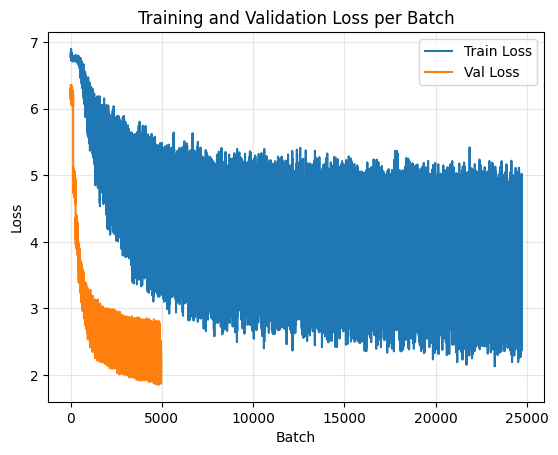

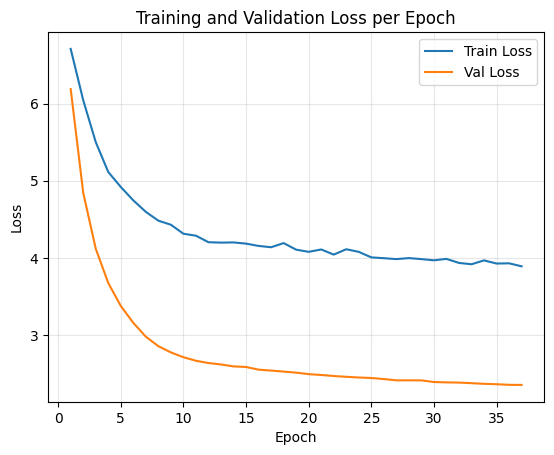

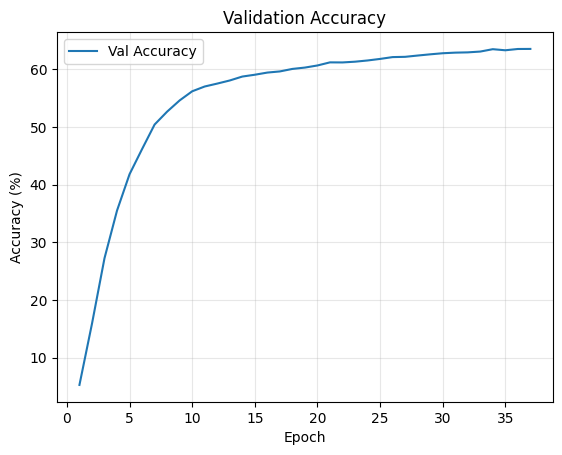

In [34]:
import math


def per_batch_to_epoch_loss(batch_losses, dataset_size):
  batches_per_epoch = math.ceil(dataset_size/64)
  num_epochs = len(batch_losses)//batches_per_epoch

  epoch_losses = []
  for epoch in range(num_epochs):
    start_idx = epoch*batches_per_epoch
    end_idx = start_idx + batches_per_epoch

    epoch_batch_losses = batch_losses[start_idx:end_idx]

    total_loss = 0
    total_samples = 0
    for i, loss in enumerate(epoch_batch_losses):
      #last batch smaller
      if i == len(epoch_batch_losses)-1:
        current_batch_size = dataset_size - (i*64)
      else:
        current_batch_size = 64
      total_loss += loss*current_batch_size
      total_samples += current_batch_size

    epoch_avg_loss = total_loss / total_samples
    epoch_losses.append(epoch_avg_loss)
  return epoch_losses

# Plot loss per batch
plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, label='Val Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Batch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('training_loss_batch.png', dpi=300, bbox_inches='tight')
plt.show()

#plot loss per epoch
train_loss_epoch = per_batch_to_epoch_loss(train_losses, 42700)
val_loss_epoch = per_batch_to_epoch_loss(val_losses, 8540)
plt.plot(range(1, len(train_loss_epoch)+1), train_loss_epoch, label='Train Loss')
plt.plot(range(1, len(val_loss_epoch)+1), val_loss_epoch, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('training_loss_epoch.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot accuracy
plt.plot(range(1, len(train_loss_epoch)+1), val_accs, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('val_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS
from datetime import datetime
import json
import torch

def extract_gps_info(exif_data):
  """
  extract gps coordinates from exif data
  returns: (latitude, longitude) or (None, None)
  """
  gps_info = {}
  if 'GPSInfo' in exif_data:
    for key, val in exif_data['GPSInfo'].items():
      decode = GPSTAGS.get(key, key)
      gps_info[decode] = val
  if not gps_info:
    return None, None
  lat = None
  lon = None
  if 'GPSLatitude' in gps_info and 'GPSLatitudeRef' in gps_info:
    lat_data = gps_info['GPSLatitude']
    lat_ref = gps_info['GPSLatitudeRef']
    #convert to floats
    lat = float(lat_data[0]) + float(lat_data[1])/60 + float(lat_data[2])/3600
    if lat_ref == 'S':
      lat = -lat
  if 'GPSLongitude' in gps_info and 'GPSLongitudeRef' in gps_info:
    lon_data = gps_info['GPSLongitude']
    lon_ref = gps_info['GPSLongitudeRef']
    #convert to floats
    lon = float(lon_data[0]) + float(lon_data[1])/60 + float(lon_data[2])/3600
    if lon_ref == 'W':
      lon = -lon
  return lat, lon

def extract_datetime_info(exif_data):
  """
  extract date and time from exif metadata
  returns: (day_of_year, minute_of_day) or (None, None)
  """
  #common exif datetime tags
  datetime_tags = ['DateTime', 'DateTimeOriginal', 'DateTimeDigitized']
  dt_str = None
  for tag in datetime_tags:
    if tag in exif_data:
      dt_str = exif_data[tag]
      break
  if not dt_str:
    return None, None
  try:
    #try standard exif format YYYY:MM:DD HH:MM:SS
    dt = datetime.strptime(dt_str, "%Y:%m:%d %H:%M:%S")
  except ValueError:
    try:
      #try iso format YYYY-MM-DDTHH:MM:SS or YYYY-MM-DD HH:MM:SS
      dt = datetime.fromisoformat(dt_str.replace(' ', 'T'))
    except ValueError:
      print(f"Could not parse datetime string: {dt_str}")
      return None, None
  day_of_year = dt.timetuple().tm_yday
  minute_of_day = dt.hour*60 + dt.minute
  return day_of_year, minute_of_day

def classify_species(model, image_path, labels, return_prob=False):
  """
  labels should be the opened labels.json, its a list of species taxonomy info
  returns: if return_prob is true, returns probability distribution over all classes
  list of top 5 species as dict
  [ {'index':index_in_labels_list,
     'taxonomy' : [species, specific_epithet, genus, ... , kingdom],
     'prob' : probability_image_is_this_species
    }, ... 5 times
  ]
  """
  #get image
  try:
    image = Image.open(image_path)
  except Exception as e:
    raise ValueError(f"Could not open image at {image_path}: {str(e)}")

  #extract exif metadata
  exif_data = {}
  exif_raw = image._getexif()
  if exif_raw:
    for tag_id, value in exif_raw.items():
      tag = TAGS.get(tag_id, tag_id)
      exif_data[tag] = value

  #get metadata
  lat, lon = extract_gps_info(exif_data)
  day_of_year, minute_of_day = extract_datetime_info(exif_data)

  #no metadata
  if lat is None or lon is None or day_of_year is None or minute_of_day is None:
    md_tensor = torch.zeros(8, dtype=torch.float32)
    has_md = torch.tensor(0, dtype=torch.float32)
    print("Insufficient metadata. Using image only.")
  #yes metadata, encode
  else:
    lat_sin, lat_cos = sinusoidal_encoding(lat, 90)
    lon_sin, lon_cos = sinusoidal_encoding(lon, 180)
    day_sin, day_cos = sinusoidal_encoding(day_of_year, 366)
    min_sin, min_cos = sinusoidal_encoding(minute_of_day, 1440)
    md_tensor = torch.tensor([lat_sin, lat_cos, lon_sin, lon_cos, day_sin, day_cos, min_sin, min_cos], dtype=torch.float32)
    has_md = torch.tensor(1, dtype=torch.float32)

  #transform image
  data_config = timm.data.resolve_model_data_config(model)
  val_transforms = timm.data.create_transform(**data_config, is_training=False)
  image_tensor = val_transforms(image.convert('RGB'))

  #add batch dim and move to device
  device='cuda' if torch.cuda.is_available() else 'cpu'
  image_tensor = image_tensor.unsqueeze(0).to(device)
  md_tensor = md_tensor.unsqueeze(0).to(device)
  has_md = has_md.unsqueeze(0).to(device)
  model = model.to(device)

  #inference
  model.eval()
  with torch.no_grad():
    logits = model(image_tensor, md_tensor, has_md).squeeze(0) #eliminate batch dim
  probs = torch.softmax(logits, 0)
  if return_prob:
    return probs
  #label probabilities, indices in labels
  top5_probs, top5_indices = torch.topk(probs, k=5)
  #turn pred to top 5 species
  results = []
  for idx, prob in zip(top5_indices.tolist(), top5_probs.tolist()):
      entry = {
          "index": idx,
          "taxonomy": labels[idx],
          "prob": prob
      }
      results.append(entry)
  return results

def sum_over_index_list(original_list, index_tuple_list):
    """
    Sums over a list of values using tuples of intervals to return
    a list of sums the size of the tuple list.
    This is used to sum the prop for a higher taxonomy level if species
    classification confidence is too low. When a confidence threshold is reached,
    the index of the largest element corresponds to the index of the name of
    the element in the taxonomy level where confidence was reached.
    :param original_list: a list of logits for every species
    :param index_tuple_list: a list of tuples [start, end] inclusive of each name
    where the difference is the number of species withing that taxonomy level name
    corresponds to the dict.keys() of the taxonomy level of interest
    :return:
    """
    sum_list = []
    for indices in index_tuple_list:
        sum_list.append(sum(original_list[indices[0]:indices[1]+1]))
    return sum_list

def classify_species_or_tax(model, image_path, labels, tax_indices, threshold=0.2):
  """
  Classifies an image of an animal to the top 5 possible species
  and if the probability of the top 1 is below threshold, gives you estimates of
  which higher taxonomy level it could belong to until the threshold is reached
  return: tuple with taxonomy level dictionary and list of top 5 dictionaries
              ({'taxonomy_level' : level name like genus or familt etc,
               'name' : if not the species, then the specific name of the tax level like panthera or canis etc.,
               'confidence' : probability of taxonomy level
               },
               [ {'index':index_in_labels_list,
                  'taxonomy' : [species, specific_epithet, genus, ... , kingdom],
                  'prob' : probability_image_is_this_species
                 }, ... 5 times
               ])
  """
  #do normal inference
  probs = classify_species(model, image_path, labels, return_prob=True)
  #do normal inference
  top5_probs, top5_indices = torch.topk(probs, k=5)
  #turn pred to top 5 species
  results = []
  for idx, prob in zip(top5_indices.tolist(), top5_probs.tolist()):
      entry = {
          "index": idx,
          "taxonomy": labels[idx],
          "prob": prob
      }
      results.append(entry)

  tax_level_confidence = {}

  #if above threshold, just return as normal
  max_prob = max(probs).float()
  if max_prob > threshold:
    tax_level_confidence['tax_level'] = "species"
    tax_level_confidence['confidence'] = max_prob
    return tax_level_confidence, results
  #else, sum over higher levels until threshold reached
  else:
    tax_levels = ['genus', 'family', 'order', 'class', 'phylum', 'kingdom']
    final_tax_level = ""
    max_prob_tax_name = ""
    for t in tax_levels:
      original_list = probs
      index_tuple_list = tax_indices[t][0] #gets list of tuples of indices for each classification at tax level
      name_list = tax_indices[t][1] #gets list of classifications for corresponding index tuples
      sum_list = sum_over_index_list(original_list, index_tuple_list) #sum probabilities for higher taxonomy level
      max_value = max(sum_list) #get
      if max_value > threshold:
        index_of_max = sum_list.index(max_value) #get index of classification with max probability
        name = name_list[index_of_max] #get name of that classification
        final_tax_level = t
        max_prob_tax_name = name
        max_prob = max_value
        break
    tax_level_confidence['tax_level'] = final_tax_level
    tax_level_confidence['name'] = max_prob_tax_name
    tax_level_confidence['confidence'] = max_prob
    return tax_level_confidence, results



In [13]:
#EXAMPLE USE

#to use the model, you need the species classifier at the top
#the sinusoidal_encoding function in the cell below the species classifier class
#and the functions in the cell above this one

#load in model using pretrained true
#ive uploaded the best mode to my gdrive, this loads it in
model = SpeciesClassifier(pretrained=True)
# model.load_pretrained_model()

#must provide an image path
image_path = "pascal_dog.jpg"
#and the labels json
with open("labels.json", "r") as f:
    labels = json.load(f)

# #pass these three in and get the top 5 species
# top5 = classify_species(model, image_path, labels)
# print(top5)

with open("tax_indices.json", "r") as f:
  tax_indices = json.load(f)

#with this, returns taxonomy level most confident, with top 5 results
#basically, if the top result is less than 20% confidence, it tries to get at least the taxonomy level
#like its genus, or if thats still too low confidence, its family, etc. until confidence is reached
taxandtop5 = classify_species_or_tax(model, image_path, labels, tax_indices)
print(taxandtop5)


Downloading...
From (original): https://drive.google.com/uc?id=1vG0T6FLkJEJBMJjRH1qnJSQFMpRDZ2Vp
From (redirected): https://drive.google.com/uc?id=1vG0T6FLkJEJBMJjRH1qnJSQFMpRDZ2Vp&confirm=t&uuid=d66a6414-0958-4bf4-ba0c-2fb82ad7e114
To: /content/model_epoch_36.pt
100%|██████████| 191M/191M [00:01<00:00, 130MB/s]


Loaded pretrained model weights
[{'index': 463, 'taxonomy': ['Glaucomys volans', 'volans', 'Glaucomys', 'Sciuridae', 'Rodentia', 'Mammalia', 'Chordata', 'Animalia'], 'prob': 0.10164956748485565}, {'index': 364, 'taxonomy': ['Lasiurus cinereus', 'cinereus', 'Lasiurus', 'Vespertilionidae', 'Chiroptera', 'Mammalia', 'Chordata', 'Animalia'], 'prob': 0.08544821292161942}, {'index': 314, 'taxonomy': ['Felis catus', 'catus', 'Felis', 'Felidae', 'Carnivora', 'Mammalia', 'Chordata', 'Animalia'], 'prob': 0.027356138452887535}, {'index': 391, 'taxonomy': ['Lepus townsendii', 'townsendii', 'Lepus', 'Leporidae', 'Lagomorpha', 'Mammalia', 'Chordata', 'Animalia'], 'prob': 0.023209232836961746}, {'index': 363, 'taxonomy': ['Lasiurus borealis', 'borealis', 'Lasiurus', 'Vespertilionidae', 'Chiroptera', 'Mammalia', 'Chordata', 'Animalia'], 'prob': 0.022149793803691864}]
({'tax_level': 'order', 'name': 'Rodentia', 'confidence': tensor(0.2206)}, [{'index': 463, 'taxonomy': ['Glaucomys volans', 'volans', 'G